In [1]:
print('hi')

hi


In [1]:
import requests

url = "https://www.chemeo.com/search?q=tb%3a%3b&p=1"
headers = {"User-Agent": "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36"}

resp = requests.get(url, headers=headers)
print(resp.status_code)
print(resp.headers.get("server"))
print(resp.text[:1000])  # посмотрите начало страницы

200
Caddy

<!DOCTYPE html>
<html lang="en"><head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<title>tb:; - Cheméo Search - Chemical &amp; Physical Properties by Cheméo</title>
<link rel="stylesheet" href="/static/css/style.css" />
<link rel="shortcut icon" type="image/icon" href="/static/img/favicon.ico">
<link rel="search" type="application/opensearchdescription+xml" href="/static/opensearch.xml" title="Cheméo Search" />
<meta name="description" content="Search chemical and physical properties for tb:;." />
</head>
<body>



<form action="/search" method="get">
<div id="hd-search">
  <div class="hd-search-logo">
    <a href="/"><img src="/static/img/logo-small.png" alt="High Quality Chemical Properties" width="150" height="57" /></a>
  </div>
  <div class="hd-search-input">
    <input type="text" name="q" value="tb:;" placeholder="Octane" />
  </div>
  <div class="hd-search-button">
    <input type="submit" value="Search" placeholder="O

In [1]:
import requests
import json

API_KEY = "9b18fb50_f3d9_4e38_8a62_bacf7883c6ae"

url = "https://www.chemeo.com/api/v1/search"
headers = {
    "Authorization": f"Bearer {API_KEY}",
    "Accept": "application/json"
}
params = {
    "q": "tb:;",   # вещества, у которых есть boiling point
    "p": 1         # первая страница
}

response = requests.get(url, headers=headers, params=params, timeout=60)

print("STATUS:", response.status_code)
print("URL:", response.url)
print("Content-Type:", response.headers.get("Content-Type"))

# если все ок, смотрим JSON
response.raise_for_status()
data = response.json()

print("Ключи ответа:", list(data.keys()))
print("total:", data.get("total"))
print("next_page:", data.get("next_page"))
print("число записей в comps:", len(data.get("comps", [])))

# сохранить тестовый ответ
with open("chemeo_tb_test_page_1.json", "w", encoding="utf-8") as f:
    json.dump(data, f, ensure_ascii=False, indent=2)

print("Тестовый ответ сохранен в chemeo_tb_test_page_1.json")

STATUS: 200
URL: https://www.chemeo.com/api/v1/search?q=tb%3A%3B&p=1
Content-Type: application/json
Ключи ответа: ['comps', 'next_page', 'prev_page', 'query', 'range', 'search_time', 'suggestions', 'total']
total: 75807
next_page: 2
число записей в comps: 100
Тестовый ответ сохранен в chemeo_tb_test_page_1.json


In [2]:
import requests
import json
import time

API_KEY = "9b18fb50_f3d9_4e38_8a62_bacf7883c6ae"

url = "https://www.chemeo.com/api/v1/search"
headers = {
    "Authorization": f"Bearer {API_KEY}",
    "Accept": "application/json"
}

page = 1

while True:
    params = {
        "q": "tb:;",
        "p": page
    }

    response = requests.get(url, headers=headers, params=params, timeout=60)
    print(f"page={page}, status={response.status_code}, url={response.url}")
    response.raise_for_status()

    data = response.json()

    file_name = f"chemeo_tb_page_{page}.json"
    with open(file_name, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)

    print(f"Сохранено: {file_name}")
    print("  total:", data.get("total"))
    print("  comps on page:", len(data.get("comps", [])))
    print("  next_page:", data.get("next_page"))

    next_page = data.get("next_page")
    if not next_page:
        print("Больше страниц нет, остановка.")
        break

    page = next_page
    time.sleep(0.3)   # не долбим API слишком быстро

page=1, status=200, url=https://www.chemeo.com/api/v1/search?q=tb%3A%3B&p=1
Сохранено: chemeo_tb_page_1.json
  total: 75807
  comps on page: 100
  next_page: 2
page=2, status=200, url=https://www.chemeo.com/api/v1/search?q=tb%3A%3B&p=2
Сохранено: chemeo_tb_page_2.json
  total: 75807
  comps on page: 100
  next_page: 3
page=3, status=200, url=https://www.chemeo.com/api/v1/search?q=tb%3A%3B&p=3
Сохранено: chemeo_tb_page_3.json
  total: 75807
  comps on page: 100
  next_page: 4
page=4, status=200, url=https://www.chemeo.com/api/v1/search?q=tb%3A%3B&p=4
Сохранено: chemeo_tb_page_4.json
  total: 75807
  comps on page: 100
  next_page: 5
page=5, status=200, url=https://www.chemeo.com/api/v1/search?q=tb%3A%3B&p=5
Сохранено: chemeo_tb_page_5.json
  total: 75807
  comps on page: 100
  next_page: 6
page=6, status=200, url=https://www.chemeo.com/api/v1/search?q=tb%3A%3B&p=6
Сохранено: chemeo_tb_page_6.json
  total: 75807
  comps on page: 100
  next_page: 7
page=7, status=200, url=https://www.chem

## Обработка `chemeo_tb_all.json` -> очищенный SDF с температурами кипения

Пайплайн (по образцу `final_practice3.ipynb`):
1. **Загрузка JSON и фильтрация источников.** Из `fixed_props.tb` берём только экспериментальные записи (отбрасываем все с флагом `calc: True` — это `joback`). Дополнительно подключаем `tpdep_props.tbp` — точки кипения при заданном давлении (там тоже только экспериментальные источники; `crippen` в Tb не появляется вовсе).
2. **Построение DataFrame** со столбцами `inchi`, `smiles`, `compound`, `cas`, `Temperature_Celsius`, `Pressure_Atm` (одна строка = одно измерение).
3. **Построение SDF из SMILES** через RDKit с `Chem.AddHs` (явные водороды нужны, чтобы протокол стандартизации `C+H` ниже корректно отличал органику от неорганики).
4. **Стандартизация молекул** (canonicalize, clean_isotopes, remove_coordinate_bonds, split_metal_salts, neutralize, отбрасывание радикалов и многокомпонентных).
5. **Дедупликация по InChI** с проверкой согласованности дубликатов (`max_spread = 20 °C`) и физическим фильтром по температуре.


In [32]:
# 1. Импорты
import os, json
import numpy as np
import pandas as pd

from chython.files import SDFRead, SDFWrite

from rdkit import Chem, RDLogger
RDLogger.DisableLog("rdApp.*")
from rdkit.Chem.inchi import MolToInchi

JSON_PATH = 'chemeo_tb_all.json'
print('Будем читать:', JSON_PATH)


Будем читать: chemeo_tb_all.json


In [33]:
# 2. Загрузка JSON
with open(JSON_PATH, 'r', encoding='utf-8') as f:
    raw = json.load(f)

comps = raw['comps']
print(f'Всего записей о соединениях: {len(comps)}')
print('Пример ключей соединения:', list(comps[0].keys()))


Всего записей о соединениях: 75807
Пример ключей соединения: ['id', 'rev', 'compound', 'other_names', 'cas', 'inchi', 'inchikey', 'formula', 'type', 'mw', 'smiles', 'drawing', 'mol2d', 'n_mixtures', 'fixed_props', 'tpdep_props', 'datasets', 'src', 'correlations']


### Сбор экспериментальных измерений

`fixed_props.tb` — нормальные точки кипения (давление = 1 атм).
`tpdep_props.tbp` — точки кипения при произвольном давлении (`p` хранится в кПа, `v` в Кельвинах).

Отсеиваем всё, что помечено `calc: True` (это `joback`, ~70.8 тыс. записей).
Никаких других расчётных источников в Tb нет (`crippen` относится только к logP / растворимости).


In [34]:
# 3. Сбор всех экспериментальных измерений в плоский список
P_STD_KPA = 101.325  # 1 атм в кПа

rows = []
n_calc_skipped = 0
n_no_struct = 0

for c in comps:
    smi = c.get('smiles')
    inchi = c.get('inchi')
    if not smi or not inchi:
        n_no_struct += 1
        continue

    base = {
        'compound': c.get('compound'),
        'cas':      c.get('cas'),
        'inchi':    inchi,
        'inchikey': c.get('inchikey'),
        'smiles':   smi,
        'mw':       c.get('mw'),
        'formula':  c.get('formula'),
    }

    # (a) нормальные точки кипения из fixed_props.tb
    for e in c.get('fixed_props', {}).get('tb', []):
        if e.get('calc'):           # отбрасываем joback и любые другие расчётные
            n_calc_skipped += 1
            continue
        v = e.get('v')
        if v is None:
            continue
        rows.append({
            **base,
            'Temperature_Celsius': float(v) - 273.15,
            'Pressure_Atm':        1.0,                 # стандартное давление
            'source':              e.get('s'),
            'reference':           e.get('r'),
            'uncertainty_K':       e.get('e'),
            'measurement_type':    'normal_bp',
        })

    # (b) точки кипения при заданном давлении из tpdep_props.tbp
    for e in c.get('tpdep_props', {}).get('tbp', []):
        if e.get('calc'):
            n_calc_skipped += 1
            continue
        v = e.get('v'); p = e.get('p')
        if v is None or p is None:
            continue
        rows.append({
            **base,
            'Temperature_Celsius': float(v) - 273.15,
            'Pressure_Atm':        float(p) / P_STD_KPA,   # кПа -> атм
            'source':              e.get('s'),
            'reference':           e.get('r'),
            'uncertainty_K':       e.get('e'),
            'measurement_type':    'pressure_dependent_bp',
        })

df = pd.DataFrame(rows)
print(f'Соединений без структуры пропущено: {n_no_struct}')
print(f'Расчётных tb/tbp отброшено:        {n_calc_skipped}')
print(f'Экспериментальных измерений всего: {len(df)}')
print(f'Уникальных InChI:                  {df["inchi"].nunique()}')
df.head()


Соединений без структуры пропущено: 0
Расчётных tb/tbp отброшено:        70823
Экспериментальных измерений всего: 18104
Уникальных InChI:                  4958


,compound,cas,inchi,inchikey,smiles,mw,formula,Temperature_Celsius,Pressure_Atm,source,reference,uncertainty_K,measurement_type
0,Hydrogen,1333-74-0,InChI=1S/H2/h1H,UFHFLCQGNIYNRP-UHFFFAOYSA-N,[H][H],2.01588,H2,-252.87,1.0,kdb-pure,NaN,NaN,normal_bp
1,neon,7440-01-9,InChI=1S/Ne,GKAOGPIIYCISHV-UHFFFAOYSA-N,[Ne],20.17970,Ne,-246.08,1.0,kdb-pure,NaN,NaN,normal_bp
2,Nitrogen,7727-37-9,InChI=1S/N2/c1-2,IJGRMHOSHXDMSA-UHFFFAOYSA-N,N#N,28.01340,N2,-195.79,1.0,kdb-pure,NaN,NaN,normal_bp
3,Nitrogen,7727-37-9,InChI=1S/N2/c1-2,IJGRMHOSHXDMSA-UHFFFAOYSA-N,N#N,28.01340,N2,-195.81,1.0,nist-webbook,"Jacobsen, Stewart, et al., 1986",NaN,normal_bp
4,Nitrogen,7727-37-9,InChI=1S/N2/c1-2,IJGRMHOSHXDMSA-UHFFFAOYSA-N,N#N,28.01340,N2,-195.75,1.0,nist-webbook,"Streng, 1971",0.3,normal_bp


In [35]:
# 4. Базовые проверки и сохранение промежуточного CSV
print('Распределение по типу измерения:')
print(df['measurement_type'].value_counts())
print()
print('Топ источников:')
print(df['source'].value_counts().head(10))
print()
print('Диапазон температур (°C):', df['Temperature_Celsius'].min(), '...', df['Temperature_Celsius'].max())
print('Диапазон давлений (атм):', df['Pressure_Atm'].min(), '...', df['Pressure_Atm'].max())

df.to_csv('chemeo_tb_measurements.csv', index=False)
print('Сохранено: chemeo_tb_measurements.csv')


Распределение по типу измерения:
measurement_type
normal_bp                17586
pressure_dependent_bp      518
Name: count, dtype: int64

Топ источников:
source
nist-webbook                       15918
kdb-pure                             829
doi_10.1016_j.fluid.2013.07.044       82
doi_10.1016_j.jct.2014.03.006         57
doi_10.1021_acs.jced.6b00221          50
doi_10.1021_acs.jced.9b00152          42
doi_10.1016_j.fluid.2013.07.024       38
doi_10.1016_j.fluid.2015.03.030       38
doi_10.1016_j.jct.2019.06.017         33
doi_10.1016_j.fluid.2018.07.014       23
Name: count, dtype: int64

Диапазон температур (°C): -273.15 ... 3826.85
Диапазон давлений (атм): 0.010856155933876142 ... 20.606957809030348
Сохранено: chemeo_tb_measurements.csv


### Запись SDF с метаданными

Для каждой строки DataFrame парсим SMILES через RDKit (`Chem.MolFromSmiles` + `Chem.AddHs`). В метаданные пишем `Temperature_Celsius`, `Pressure_Atm`, `InChI`, `SMILES_orig`, `CAS`, `compound`, `source`. Дублей на этом шаге не убираем — это сделает финальная ячейка (по образцу `final_practice3`).


In [36]:
# 5. Запись SDF из SMILES через RDKit с явными водородами
# Используем RDKit, потому что протокол стандартизации
# ниже проверяет наличие как C, так и H в атомах молекулы. chython по умолчанию
# хранит H неявно, поэтому пишем SDF через RDKit с AddHs — тогда chython при
# чтении SDF увидит явные H, и условие "'C' in atoms and 'H' in atoms" сработает.
from rdkit.Chem import SDWriter, AllChem

SDF_RAW = "chemeo_tb_raw.sdf"

n_ok = 0
n_fail = 0
fail_examples = []

writer = SDWriter(SDF_RAW)
for _, row in df.iterrows():
    rdmol = Chem.MolFromSmiles(row["smiles"])
    if rdmol is None:
        n_fail += 1
        if len(fail_examples) < 5:
            fail_examples.append(row["smiles"])
        continue

    # Явные водороды — критично, чтобы дальше прошёл фильтр C+H
    rdmol = Chem.AddHs(rdmol)

    rdmol.SetProp("Temperature_Celsius", str(row["Temperature_Celsius"]))
    rdmol.SetProp("Pressure_Atm",        str(row["Pressure_Atm"]))
    rdmol.SetProp("InChI",               str(row["inchi"]))
    rdmol.SetProp("SMILES_orig",         str(row["smiles"]))
    rdmol.SetProp("CAS",                 str(row["cas"] or ""))
    rdmol.SetProp("compound",            str(row["compound"] or ""))
    rdmol.SetProp("source",              str(row["source"] or ""))
    rdmol.SetProp("measurement_type",    str(row["measurement_type"]))

    writer.write(rdmol)
    n_ok += 1
writer.close()

print(f"Записано в {SDF_RAW}: {n_ok}")
print(f"Не удалось распарсить SMILES: {n_fail}")
for s in fail_examples:
    print("  bad SMILES:", s)


Записано в chemeo_tb_raw.sdf: 18103
Не удалось распарсить SMILES: 1
  bad SMILES: CC[AlH3](CC)CC


### Стандартизация молекул

Повторяет шаг из `final_practice3`: оставляем только органику (есть и C, и H), канонизируем, чистим изотопы / координационные связи / соли, нейтрализуем, отбрасываем многокомпонентные и радикалы. Параллельно пишем `chemeo_nbp_stereo.sdf` (со стерео) и `chemeo_nbp_final.sdf` — оба пригодятся на следующем шаге.


In [37]:
# 6. Стандартизация (по образцу final_practice3)
neorg_mol = flag_is = flag_coord = flag_salts = 0
flag_neutr = flag_components = flag_radicals = flag_final_molecules = 0

with open(SDF_RAW) as f, SDFRead(f) as sdf_reader, \
     SDFWrite('chemeo_neorg_molecules.sdf') as neorg_file, \
     SDFWrite('chemeo_nbp_clean_stereo.sdf') as clean_ster, \
     SDFWrite('chemeo_nbp_stereo.sdf') as ster_file, \
     SDFWrite('chemeo_nbp_final.sdf') as final_file:

    for m in sdf_reader:
        unique_atoms = {a[1].atomic_symbol for a in list(m.atoms())}

        if 'C' in unique_atoms and 'H' in unique_atoms:
            m.canonicalize(logging=True, fix_tautomers=False)

            if m.clean_isotopes():           flag_is     += 1
            if m.remove_coordinate_bonds():  flag_coord  += 1
            if m.split_metal_salts(logging=True): flag_salts += 1
            if m.neutralize():               flag_neutr  += 1

            m.canonicalize(logging=True, fix_tautomers=True)

            if m.connected_components_count > 1:
                flag_components += 1
            elif m.is_radical:
                flag_radicals += 1
            else:
                ster_file.write(m)
                m.clean_stereo()
                clean_ster.write(m)
                final_file.write(m)
                flag_final_molecules += 1
        else:
            neorg_file.write(m)
            neorg_mol += 1

print('Результаты стандартизации:')
print('=' * 40)
for name, val in [
    ('neorg_mol', neorg_mol), ('flag_is', flag_is), ('flag_coord', flag_coord),
    ('flag_salts', flag_salts), ('flag_neutr', flag_neutr),
    ('flag_components', flag_components), ('flag_radicals', flag_radicals),
    ('flag_final_molecules', flag_final_molecules),
]:
    print(name.ljust(22) + str(val).rjust(18))
print('=' * 40)


Результаты стандартизации:
neorg_mol                            538
flag_is                                0
flag_coord                             1
flag_salts                             0
flag_neutr                             0
flag_components                        2
flag_radicals                          1
flag_final_molecules               17562


### Дедупликация по InChI с фильтрами

Группируем по InChI; если у одной молекулы несколько Tb и их разброс ≤ `max_spread` (20 °C по умолчанию) — берём среднее, иначе считаем измерения противоречивыми и выбрасываем. Дополнительно физический фильтр: −200 … 700 °C. Функция перенесена 1-в-1 из `final_practice3`.

**Замечание.** В chemeo много измерений при разном давлении (`tbp`), поэтому у одной и той же молекулы Tb могут сильно расходиться — и они корректно отсеются фильтром противоречий. Если потом захотите оставить давление как фичу, дедупликацию надо вести по `(inchi, round(P, 2))` — скажите, добавлю.


In [38]:
# 7. Дедупликация по InChI + фильтры (по образцу final_practice3)
def chython_to_rdkit(mol_ch):
    try:
        return Chem.MolFromSmiles(str(mol_ch))
    except Exception:
        return None


def process_sdf(input_sdf, output_sdf, use_stereo=True, max_spread=20.0,
                temp_min=-200.0, temp_max=700.0):
    options = "" if use_stereo else "/SNon"
    inchi_groups = {}
    failed = 0
    total_read = 0

    with open(input_sdf) as f, SDFRead(f) as reader:
        for mol_ch in reader:
            total_read += 1
            rdmol = chython_to_rdkit(mol_ch)
            if rdmol is None:
                failed += 1
                continue
            inchi = MolToInchi(rdmol, options=options)
            if not inchi:
                failed += 1
                continue
            if inchi not in inchi_groups:
                inchi_groups[inchi] = {"mol": mol_ch, "temps": [], "pressures": []}
            # chython.SDFRead приписывает к ключам ' (N)' где N - номер записи в файле.
            # Поэтому нормализуем имя ключа, отбрасывая суффикс.
            meta = {k.split(' (')[0]: v for k, v in mol_ch.meta.items()}
            if "Temperature_Celsius" in meta:
                inchi_groups[inchi]["temps"].append(float(meta["Temperature_Celsius"]))
            if "Pressure_Atm" in meta:
                inchi_groups[inchi]["pressures"].append(float(meta["Pressure_Atm"]))

    n_unique = len(inchi_groups)
    print(f"  Прочитано: {total_read}, не распознано: {failed}")
    print(f"  Уникальных InChI: {n_unique}, дубликатов: {total_read - failed - n_unique}")

    kept_mols = []
    removed_conflict = 0
    removed_physical = 0

    for data in inchi_groups.values():
        mol = data["mol"]
        temps = data["temps"]
        if not temps:
            continue
        spread = max(temps) - min(temps) if len(temps) > 1 else 0.0
        if spread > max_spread:
            removed_conflict += 1
            continue
        t_mean = float(np.mean(temps))
        if not (temp_min <= t_mean <= temp_max):
            removed_physical += 1
            continue
        # Чистим meta от chython-овских суффиксов вида "Key (N)" -- иначе
        # в выходном SDF будут дубли тегов. Сохраняем только нормализованные
        # ключи + перезаписываем числовые поля усреднёнными значениями.
        clean_meta = {}
        for k, v in mol.meta.items():
            base_key = k.split(' (')[0]
            clean_meta.setdefault(base_key, v)
        clean_meta["Temperature_Celsius"] = t_mean
        if data["pressures"]:
            clean_meta["Pressure_Atm"] = float(np.mean(data["pressures"]))
        clean_meta["n_measurements"] = len(temps)
        mol.meta.clear()
        mol.meta.update(clean_meta)
        kept_mols.append((mol, t_mean))

    print(f"  Удалено из-за противоречивых измерений (разброс > {max_spread}°C): {removed_conflict}")
    print(f"  Удалено физически невозможных (< {temp_min} или > {temp_max}°C): {removed_physical}")

    with SDFWrite(output_sdf) as writer:
        for mol, _ in kept_mols:
            writer.write(mol)

    if kept_mols:
        temps_final = np.array([t for _, t in kept_mols])
        print(f"  Итого сохранено: {len(kept_mols)}")
        print(f"  Финальный диапазон: [{temps_final.min():.1f}, {temps_final.max():.1f}]°C, "
              f"median={np.median(temps_final):.1f}°C")
    print(f"  Сохранено в: {output_sdf}")


print("=== chemeo_nbp_stereo.sdf ===")
process_sdf("chemeo_nbp_stereo.sdf", "chemeo_nbp_stereo_clean.sdf", use_stereo=True)

print()
print("=== chemeo_nbp_final.sdf ===")
process_sdf("chemeo_nbp_final.sdf", "chemeo_nbp_final_clean.sdf", use_stereo=False)


=== chemeo_nbp_stereo.sdf ===
  Прочитано: 17562, не распознано: 59
  Уникальных InChI: 4540, дубликатов: 12963
  Удалено из-за противоречивых измерений (разброс > 20.0°C): 219
  Удалено физически невозможных (< -200.0 или > 700.0°C): 0
  Итого сохранено: 4321
  Финальный диапазон: [-161.7, 525.1]°C, median=175.8°C
  Сохранено в: chemeo_nbp_stereo_clean.sdf

=== chemeo_nbp_final.sdf ===
  Прочитано: 17562, не распознано: 59
  Уникальных InChI: 4540, дубликатов: 12963
  Удалено из-за противоречивых измерений (разброс > 20.0°C): 219
  Удалено физически невозможных (< -200.0 или > 700.0°C): 0
  Итого сохранено: 4321
  Финальный диапазон: [-161.7, 525.1]°C, median=175.8°C
  Сохранено в: chemeo_nbp_final_clean.sdf


## EDA / валидация датасета для ML

Проверяем, что данные пригодны для построения модели Tb:
1. **Гистограмма Tb** — диапазон и форма распределения
2. **Scatter MW vs Tb, HeavyAtoms vs Tb** — физическая закономерность (большие молекулы → выше Tb)
3. **Sanity-check эталонных молекул** — известные NBP (вода 100, этанол 78.4, метан −161.5)
4. **Распределение элементов** — какие атомы вообще встречаются
5. **n_measurements** — сколько литературных измерений усреднено на молекулу
6. **Поиск выбросов** — точки, далёкие от линии MW↔Tb


In [44]:
# 8. EDA: загружаем итоговый SDF в DataFrame для анализа
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors

FINAL_SDF = "chemeo_nbp_final_clean.sdf"

records = []
for m in Chem.SDMolSupplier(FINAL_SDF, removeHs=False):
    if m is None:
        continue
    rec = {
        "smiles":    Chem.MolToSmiles(m),
        "n_heavy":   m.GetNumHeavyAtoms(),
        "mw":        Descriptors.MolWt(m),
        "n_rings":   rdMolDescriptors.CalcNumRings(m),
        "n_arom":    rdMolDescriptors.CalcNumAromaticRings(m),
        "logp":      Descriptors.MolLogP(m),
        "tpsa":      Descriptors.TPSA(m),
        "n_hbd":     rdMolDescriptors.CalcNumHBD(m),
        "n_hba":     rdMolDescriptors.CalcNumHBA(m),
        "n_rot":     rdMolDescriptors.CalcNumRotatableBonds(m),
    }
    for tag in ("Temperature_Celsius","Pressure_Atm","compound","CAS",
                "source","measurement_type","n_measurements","InChI"):
        if m.HasProp(tag):
            rec[tag] = m.GetProp(tag)
    records.append(rec)

eda = pd.DataFrame(records)
eda["Temperature_Celsius"] = eda["Temperature_Celsius"].astype(float)
eda["Pressure_Atm"]        = eda["Pressure_Atm"].astype(float)
if "n_measurements" in eda:
    eda["n_measurements"]  = eda["n_measurements"].astype(int)

print("Размер итогового датасета:", eda.shape)
print()
print("Описательная статистика по Tb (°C):")
print(eda["Temperature_Celsius"].describe().round(2))
print()
print("Описательная статистика по MW:")
print(eda["mw"].describe().round(2))
eda.head()


Размер итогового датасета: (4321, 18)

Описательная статистика по Tb (°C):
count    4321.00
mean      178.14
std        77.84
min      -161.71
25%       124.50
50%       175.75
75%       229.25
max       525.05
Name: Temperature_Celsius, dtype: float64

Описательная статистика по MW:
count    4321.00
mean      144.06
std        51.88
min        16.04
25%       112.13
50%       136.19
75%       167.05
max       581.55
Name: mw, dtype: float64


,smiles,n_heavy,mw,n_rings,n_arom,logp,tpsa,n_hbd,n_hba,n_rot,Temperature_Celsius,Pressure_Atm,compound,CAS,source,measurement_type,n_measurements,InChI
0,[CH4:1],1,16.043,0,0,0.6361,0.0,0,0,0,-161.705714,1.0,Methane,74-82-8,kdb-pure,normal_bp,14,InChI=1S/CH4/h1H4
1,[CH3:1][CH:2]([CH3:3])[CH2:4][C:5](=[O:6])[O:7...,10,144.214,0,0,1.9841,26.3,0,2,3,-131.350000,1.0,"Butanoic acid, 3-methyl-, 1-methylethyl ester",32665-23-9,nist-webbook,normal_bp,1,"InChI=1S/C8H16O2/c1-6(2)5-8(9)10-7(3)4/h6-7H,5..."
2,[CH2:1]=[CH2:2],2,28.054,0,0,0.8022,0.0,0,0,0,-103.871000,1.0,Ethylene,74-85-1,kdb-pure,normal_bp,10,InChI=1S/C2H4/c1-2/h1-2H2
3,[CH3:1][CH2:2][CH2:3][CH2:4][O:5][C:6](=[O:7])...,11,158.241,0,0,2.3758,26.3,0,2,5,-97.450000,1.0,"Butanoic acid, 3-methyl-, butyl ester",109-19-3,nist-webbook,normal_bp,1,"InChI=1S/C9H18O2/c1-4-5-6-11-9(10)7-8(2)3/h8H,..."
4,[CH3:1][CH3:2],2,30.070,0,0,1.0262,0.0,0,0,0,-88.537917,1.0,Ethane,74-84-0,kdb-pure,normal_bp,24,InChI=1S/C2H6/c1-2/h1-2H3


C:\Users\User\AppData\Local\Temp\ipykernel_11416\677822982.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=["0","1","2","3",">=4"], showfliers=False)


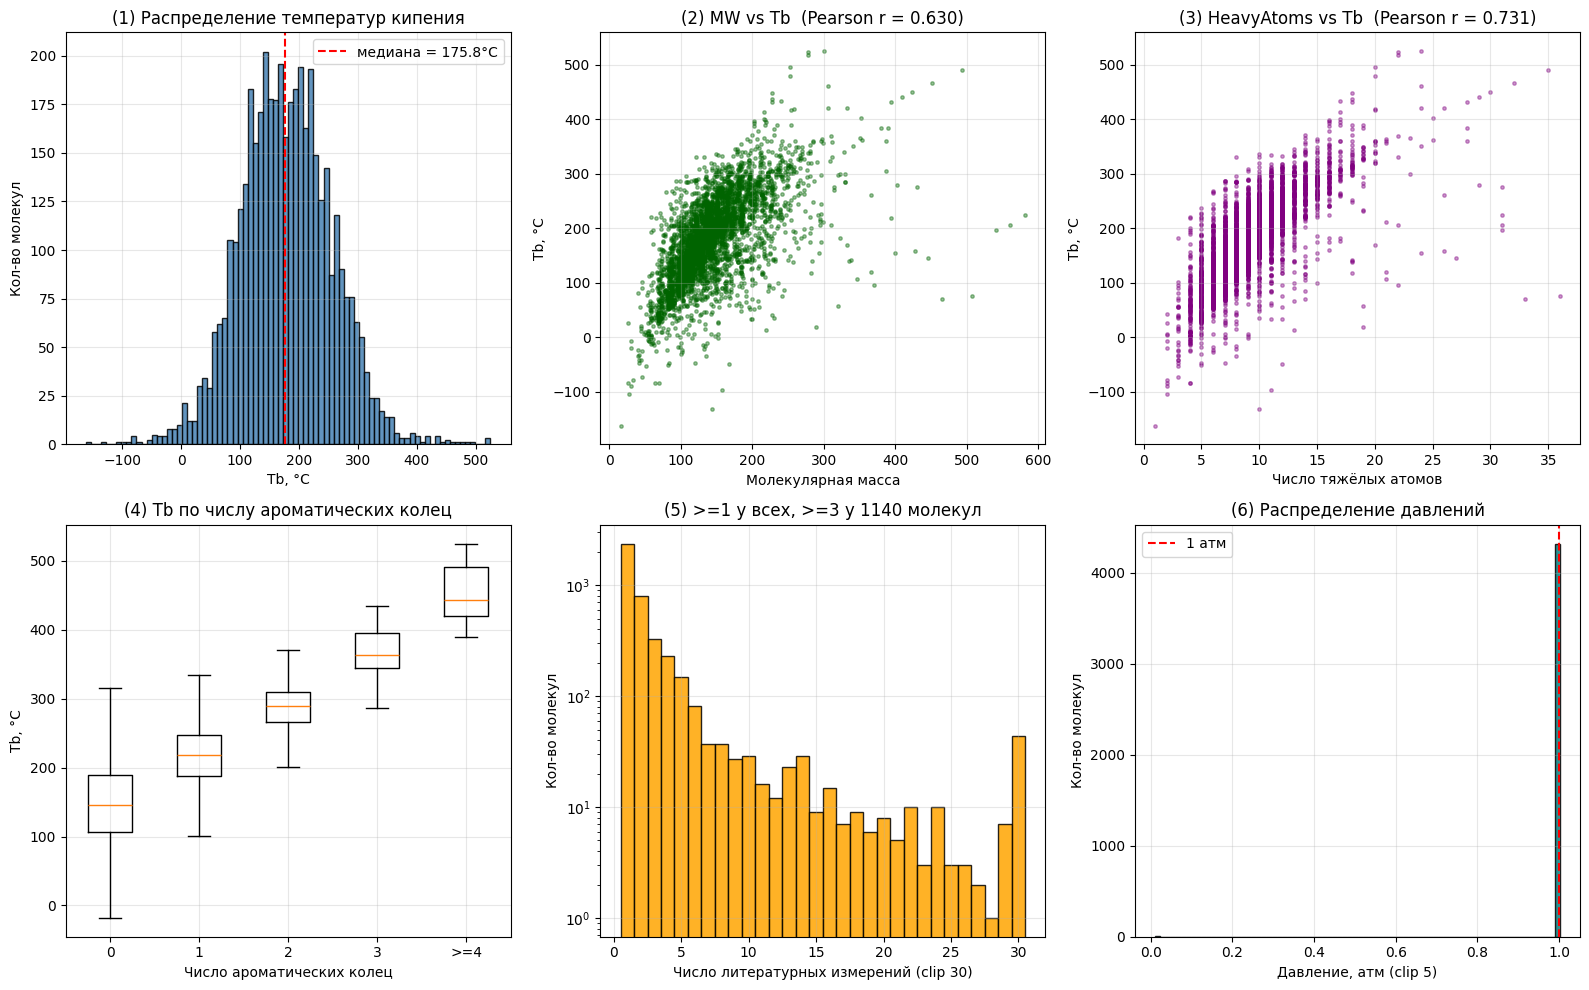

Сохранено: eda_dashboard.png


In [45]:
# 9. Основной EDA-дашборд: 6 графиков
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# (1) Гистограмма Tb
ax = axes[0, 0]
ax.hist(eda["Temperature_Celsius"], bins=80, color="steelblue", edgecolor="black", alpha=0.85)
med = eda["Temperature_Celsius"].median()
ax.axvline(med, color="red", linestyle="--", label="медиана = {:.1f}°C".format(med))
ax.set_xlabel("Tb, °C"); ax.set_ylabel("Кол-во молекул")
ax.set_title("(1) Распределение температур кипения")
ax.legend(); ax.grid(alpha=0.3)

# (2) MW vs Tb
ax = axes[0, 1]
ax.scatter(eda["mw"], eda["Temperature_Celsius"], s=6, alpha=0.4, color="darkgreen")
ax.set_xlabel("Молекулярная масса"); ax.set_ylabel("Tb, °C")
corr_mw = eda[["mw","Temperature_Celsius"]].corr().iloc[0,1]
ax.set_title("(2) MW vs Tb  (Pearson r = {:.3f})".format(corr_mw))
ax.grid(alpha=0.3)

# (3) HeavyAtoms vs Tb
ax = axes[0, 2]
ax.scatter(eda["n_heavy"], eda["Temperature_Celsius"], s=6, alpha=0.4, color="purple")
ax.set_xlabel("Число тяжёлых атомов"); ax.set_ylabel("Tb, °C")
corr_ha = eda[["n_heavy","Temperature_Celsius"]].corr().iloc[0,1]
ax.set_title("(3) HeavyAtoms vs Tb  (Pearson r = {:.3f})".format(corr_ha))
ax.grid(alpha=0.3)

# (4) Boxplot Tb по числу ароматических колец
ax = axes[1, 0]
arom_bin = eda["n_arom"].clip(upper=4)
groups = [eda.loc[arom_bin == k, "Temperature_Celsius"].values for k in range(5)]
ax.boxplot(groups, labels=["0","1","2","3",">=4"], showfliers=False)
ax.set_xlabel("Число ароматических колец"); ax.set_ylabel("Tb, °C")
ax.set_title("(4) Tb по числу ароматических колец")
ax.grid(alpha=0.3)

# (5) Распределение n_measurements (если есть)
ax = axes[1, 1]
if "n_measurements" in eda.columns:
    nm = eda["n_measurements"]
    upper = int(min(nm.max(), 30))
    bins = np.arange(1, upper + 2) - 0.5
    ax.hist(nm.clip(upper=upper), bins=bins, color="orange", edgecolor="black", alpha=0.85)
    ax.set_xlabel("Число литературных измерений (clip {})".format(upper))
    ax.set_ylabel("Кол-во молекул")
    ax.set_yscale("log")
    ax.set_title("(5) >=1 у всех, >=3 у {} молекул".format((nm>=3).sum()))
else:
    ax.text(0.5, 0.5, "n_measurements нет\n(перезапустите ячейку 15)",
            ha="center", va="center", transform=ax.transAxes)
    ax.set_title("(5) Согласованность измерений")
ax.grid(alpha=0.3)

# (6) Распределение давлений
ax = axes[1, 2]
ax.hist(eda["Pressure_Atm"].clip(upper=5), bins=80, color="teal", edgecolor="black", alpha=0.85)
ax.axvline(1.0, color="red", linestyle="--", label="1 атм")
ax.set_xlabel("Давление, атм (clip 5)"); ax.set_ylabel("Кол-во молекул")
ax.set_title("(6) Распределение давлений")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("eda_dashboard.png", dpi=110, bbox_inches="tight")
plt.show()
print("Сохранено: eda_dashboard.png")


In [46]:
# 10. Sanity-check: ищем эталонные молекулы по InChIKey (надёжный идентификатор).
# Поиск по полю compound НЕ работает: chemeo может называть воду "Hydrogen oxide",
# этанол "Ethyl alcohol" и т.п. — поэтому ищем по канонической структуре.
reference = [
    # (name,                       canonical SMILES,           lit. Tb °C)
    ("Methane",                    "C",                         -161.5),
    ("Ethane",                     "CC",                         -88.6),
    ("Ethanol",                    "CCO",                          78.4),
    ("Methanol",                   "CO",                           64.7),
    ("Water",                      "O",                           100.0),
    ("Benzene",                    "c1ccccc1",                     80.1),
    ("Toluene",                    "Cc1ccccc1",                   110.6),
    ("Acetone",                    "CC(C)=O",                      56.1),
    ("Diethyl ether",              "CCOCC",                        34.6),
    ("n-Hexane",                   "CCCCCC",                       68.7),
    ("n-Heptane",                  "CCCCCCC",                      98.4),
    ("n-Octane",                   "CCCCCCCC",                    125.7),
    ("Chloroform",                 "ClC(Cl)Cl",                    61.2),
    ("Acetic acid",                "CC(=O)O",                     118.1),
]

# Строим индекс InChIKey -> Tb по нашему датасету
from rdkit.Chem.inchi import MolToInchiKey
key2tb = {}
for _, row in eda.iterrows():
    smi = row["smiles"]
    # убираем atom-map, если есть
    m = Chem.MolFromSmiles(smi)
    if m is None: continue
    for a in m.GetAtoms():
        a.SetAtomMapNum(0)
    k = MolToInchiKey(m)
    key2tb.setdefault(k, []).append(row["Temperature_Celsius"])

print("{:18s} {:>10s} {:>12s} {:>9s}".format("Compound","Lit. Tb","Our Tb","delta"))
print("-" * 55)
found = 0
for name, smi, lit in reference:
    m = Chem.MolFromSmiles(smi)
    k = MolToInchiKey(m)
    if k in key2tb:
        our = float(np.mean(key2tb[k]))
        diff = our - lit
        flag = "" if abs(diff) <= 3.0 else "  <-- расхождение"
        print("{:18s} {:>10.1f} {:>12.2f} {:>+9.2f}{}".format(name, lit, our, diff, flag))
        found += 1
    else:
        print("{:18s} {:>10.1f} {:>12s}".format(name, lit, "нет в датасете"))

print()
print("Найдено {} из {} эталонных молекул".format(found, len(reference)))


Compound              Lit. Tb       Our Tb     delta
-------------------------------------------------------
Methane                -161.5      -161.71     -0.21
Ethane                  -88.6       -88.54     +0.06
Ethanol                  78.4 нет в датасете
Methanol                 64.7 нет в датасете
Water                   100.0 нет в датасете
Benzene                  80.1        79.51     -0.59
Toluene                 110.6 нет в датасете
Acetone                  56.1        56.16     +0.06
Diethyl ether            34.6        34.63     +0.03
n-Hexane                 68.7        68.59     -0.11
n-Heptane                98.4 нет в датасете
n-Octane                125.7 нет в датасете
Chloroform               61.2        61.17     -0.03
Acetic acid             118.1 нет в датасете

Найдено 7 из 14 эталонных молекул


In [47]:
# 11. Распределение элементов и потенциальные выбросы
from collections import Counter
elem_count = Counter()
for smi in eda["smiles"]:
    m = Chem.MolFromSmiles(smi)
    if m is None: continue
    for a in m.GetAtoms():
        elem_count[a.GetSymbol()] += 1

print("Распределение элементов (по числу атомов в датасете):")
for elem, n in elem_count.most_common(15):
    print("  {:3s} {:>8d}".format(elem, n))

# Выбросы: линейная модель Tb ~ MW, остатки > 3 sigma — кандидаты в выбросы
x = eda["mw"].values; y = eda["Temperature_Celsius"].values
coef = np.polyfit(x, y, 1)
y_pred = np.polyval(coef, x)
resid = y - y_pred
sigma = float(resid.std())
mask_out = np.abs(resid) > 3 * sigma
outliers = eda.assign(residual=resid).loc[mask_out].copy()
outliers = outliers.reindex(outliers["residual"].abs().sort_values(ascending=False).index)

print()
print("Линейная аппроксимация: Tb ~= {:.3f}*MW + {:.1f},  sigma остатков = {:.1f} °C".format(
    coef[0], coef[1], sigma))
print("Кандидаты в выбросы (|остаток| > 3 sigma): {} молекул из {}".format(len(outliers), len(eda)))
print()
print("Топ-15 самых сильных выбросов:")
cols = [c for c in ["compound","CAS","mw","Temperature_Celsius","residual","source"] if c in outliers.columns]
print(outliers[cols].head(15).to_string(index=False))


Распределение элементов (по числу атомов в датасете):
  C      33330
  O       3579
  N       1138
  F        950
  Cl       881
  Br       319
  S        238
  Si       122
  I         63
  P         14
  B          5
  Se         2
  Sn         2
  As         1
  Ge         1

Линейная аппроксимация: Tb ~= 0.946*MW + 41.9,  sigma остатков = 60.4 °C
Кандидаты в выбросы (|остаток| > 3 sigma): 45 молекул из 4321

Топ-15 самых сильных выбросов:
                                                 compound        CAS      mw  Temperature_Celsius    residual       source
                                          Hexatriacontane   630-06-8 506.988                75.73 -445.614777     kdb-pure
                                           Tritriacontane   630-05-7 464.907                71.00 -410.550485     kdb-pure
                1h,1h,2h,2h-Perfluorodecyltrichlorosilane 78560-44-8 581.553               223.85 -368.007868 nist-webbook
           1h,1h,2h,2h-Perfluorodecylmethyldichlorosilane  31

### Как читать результаты

* **График (1)** должен быть «холмом», простирающимся от низких температур (газы) до ~400–500 °C. Бимодальности / резких пиков быть не должно.
* **Графики (2)–(3)**: ожидаем Pearson r > 0.7. Если меньше — данные сильно зашумлены.
* **График (4)**: чем больше ароматических колец, тем выше медиана Tb (растёт π-π стэкинг и MW).
* **График (5)**: чем больше у вас молекул с n_measurements ≥ 2–3, тем надёжнее усреднённые значения.
* **Sanity-check** (ячейка 10): отклонение от литературы > 3 °C — повод присмотреться к источникам.
* **Выбросы** (ячейка 11): кандидаты на ручной осмотр. Часто это либо ошибка в JSON, либо реально экзотические молекулы (например, ионные жидкости, у которых Tb не имеет физического смысла).


### Финальная очистка: выбрасываем выбросы (Tm попавшие в Tb)

Линейная модель `Tb ≈ 0.95·MW + 42` даёт σ=60 °C. У 45 молекул остаток >3σ — это длинноцепочечные алканы и эфиры, у которых **в chemeo перепутаны Tm и Tb** (классическая ошибка парсинга). Их надо отбросить — иначе ML-модель будет учиться на шуме.

Создаём `chemeo_nbp_ml_ready.sdf` без этих 45 молекул.


До фильтрации: 4321
Отброшено выбросов (|остаток| > 3 sigma): 45
После фильтрации: 4276
Сохранено в chemeo_nbp_ml_ready.sdf: 4276

Финальный датасет (ML-ready):
count    4276.00
mean      178.82
std        75.84
min      -103.87
25%       125.11
50%       176.53
75%       229.79
max       490.05
Name: Temperature_Celsius, dtype: float64


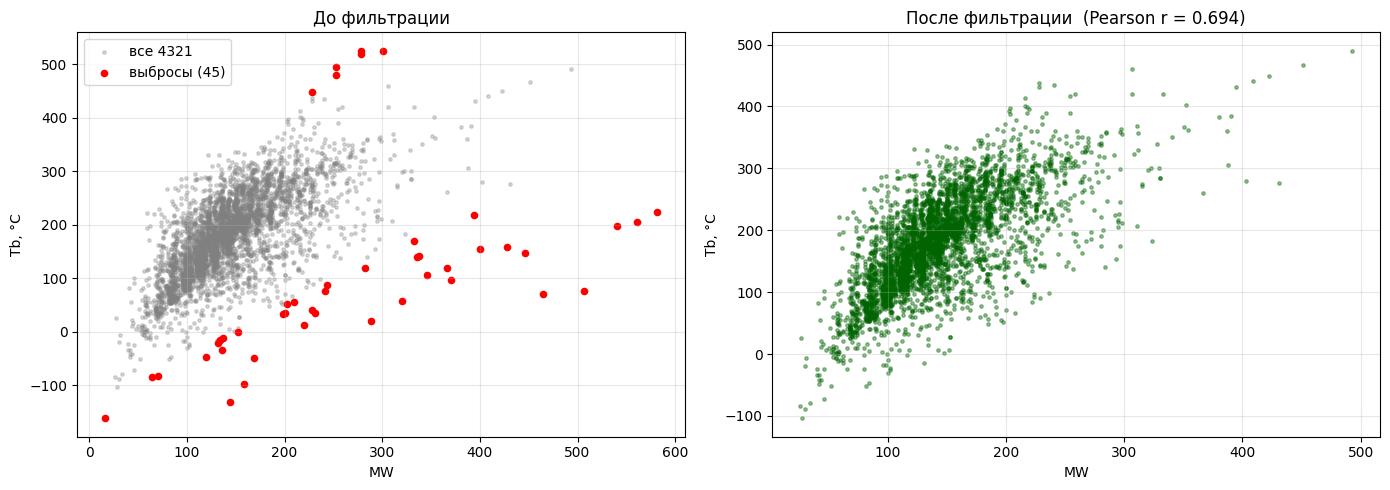

Сохранено: eda_after_cleanup.png


In [48]:
# 12. Финальная очистка: отбрасываем точки с |остаток| > 3 sigma
# и сохраняем готовый для ML датасет.
from rdkit.Chem import SDWriter

keep_mask = ~mask_out  # mask_out был задан в ячейке 11
filtered = eda.loc[keep_mask].copy()
print("До фильтрации:", len(eda))
print("Отброшено выбросов (|остаток| > 3 sigma):", int(mask_out.sum()))
print("После фильтрации:", len(filtered))

# Перечитываем финальный SDF, оставляем только те, что прошли фильтр
keep_inchis = set(filtered["InChI"])
out_path = "chemeo_nbp_ml_ready.sdf"
writer = SDWriter(out_path)
n_written = 0
for m in Chem.SDMolSupplier("chemeo_nbp_final_clean.sdf", removeHs=False):
    if m is None: continue
    if m.HasProp("InChI") and m.GetProp("InChI") in keep_inchis:
        writer.write(m)
        n_written += 1
writer.close()
print(f"Сохранено в {out_path}: {n_written}")

# Финальная статистика
print()
print("Финальный датасет (ML-ready):")
print(filtered["Temperature_Celsius"].describe().round(2))

# Перестроим scatter MW vs Tb до/после
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.scatter(eda["mw"], eda["Temperature_Celsius"], s=6, alpha=0.3, color="gray", label="все 4321")
ax.scatter(eda.loc[mask_out,"mw"], eda.loc[mask_out,"Temperature_Celsius"],
           s=20, color="red", label=f"выбросы ({int(mask_out.sum())})")
ax.set_xlabel("MW"); ax.set_ylabel("Tb, °C")
ax.set_title("До фильтрации"); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.scatter(filtered["mw"], filtered["Temperature_Celsius"], s=6, alpha=0.4, color="darkgreen")
r_after = filtered[["mw","Temperature_Celsius"]].corr().iloc[0,1]
ax.set_xlabel("MW"); ax.set_ylabel("Tb, °C")
ax.set_title("После фильтрации  (Pearson r = {:.3f})".format(r_after))
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("eda_after_cleanup.png", dpi=110, bbox_inches="tight")
plt.show()
print("Сохранено: eda_after_cleanup.png")
